# Module: Loading HACC stellar catalog

> Importing the stellar catalogs compiled from HACC. This module may be edited for a different file reader if necessary. 

## The entries in the current stellar catalog are: 

### *[fof_halo_tag, if_satellite, galaxy_tag, stellar_idx, metallicity, mass, age, x, y, z, vx, vy, vz]*

- galaxy_tag: Tags to galaxies given in the HACC datasets
- stellar idx: Unique ID for individual particles
- metallicity: Fraction of the metals in the stellar particles (Not rescaled by Zsun)
- mass: Mass of the stellar particle in Msun units
- age: Age of the stellar particles in 1/H0 units 
- x, y, z: Particle positions in Mpc/h units
- vx, vy, vz: Velocity of the particles

In [ ]:
#| default_exp load_sim_stellar_catalog

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export

import numpy as np
import os
import matplotlib.pylab as plt
import pkg_resources
import logging
import opencosmo as oc

In [ ]:
#| hide 

import seaborn as sns
import pandas as pd

In [ ]:
#| export

GALS_DIR = "data/test_hacc_stellar_catalog/"
GALS_FILE = pkg_resources.resource_stream("watercolor", GALS_DIR + "Gal_Z0.txt").name

# OPEN_COSMO_FILE: path to the large HDF5 data file.
# This file is too large to bundle with the package, so we look for it
# next to the installed small data files, or fall back to None.
_opencosmo_candidate = os.path.join(os.path.dirname(GALS_FILE), "haloparticles.hdf5")
OPEN_COSMO_FILE = _opencosmo_candidate if os.path.exists(_opencosmo_candidate) else None

In [ ]:
#| export

Z_SOLAR_HACC = 0.012899 # Solar metallicity value in HACC Hydro
Z_SOLAR_PADOVA = 0.019 # Solar metallicity value in Padova 
H0 = 71.0 # Hubble Constant in HACC Hydro

In [ ]:
#| export

def _convert_metallicity(hacc_metallicity:np.array=None, # Metallicity values from HACC  
                         Z_solar:np.float32=Z_SOLAR_PADOVA, # Z_solar value from Padova
                        )-> np.array: # Metallicity array in Z/Z_solar units
    return hacc_metallicity/Z_solar

def _convert_age(hacc_age:np.array=None, #Age in 1/H0 units 
                 H0:np.float32=H0, # LastJourney H0 value
                )-> np.array: #Age in Gyr 
    '''
    (hacc_age is in 1/H0 units)
    H0 = (71 km/s/Mpc) x (1 Mpc/3.08 x 1e19 km) = 2.37 x 1e−18 1/s
    '''
    # https://www.e-education.psu.edu/astro801/content/l10_p5.html
    
    H0_per_sec = H0*(1/(3.08*1e19)) #seconds
    one_over_H0 = 1/H0_per_sec/(3.1536*1e16)
    # age_hydro_gyr = hacc_age*one_over_H0     ### NOT SURE IF THE AGE is COSMIC (13.7 - age) or (age)

    age_hydro_gyr = one_over_H0 - hacc_age*one_over_H0  
    
    # print(age_hydro_gyr, one_over_H0)
    
    return age_hydro_gyr

In [ ]:
#| export

def load_hacc_galaxy_data(fileIn:str=GALS_FILE, # Input galaxy catalog file from HACC hydro sim
                              Z_solar:np.float32=Z_SOLAR_PADOVA, #Solar metallicity
                              H0:np.float32=H0, # Hubble constant
                              ) -> tuple: # galaxy_tag, stellar_indices, metallicity, mass, age, x, y, z
    
    fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z, vx, vy, vz = np.loadtxt(fileIn, 
                                                                 skiprows=1, 
                                                                 unpack=True)
    
    metal_z_solar = _convert_metallicity(metal, Z_solar)
    
    age_gyr = _convert_age(age, H0)
    
    return fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal_z_solar, mass, age_gyr, x, y, z, vx, vy, vz

In [ ]:
#| export

def load_opencosmo_collection(
    particle_file_path:str = None, # Path to the OpenCosmo particle file
    catalog_file_path:str = None, # Path to the OpenCosmo catalog file (optional for single-file format)
    ) -> oc.StructureCollection: # OpenCosmo particle collection

    files = [f for f in [particle_file_path, catalog_file_path] if f is not None]
    collection = oc.open(*files).with_units("physical")
    return collection

In [ ]:
#| export

def read_particles_in_a_galaxy(
    particle_file_path: str = None, # Path to the HDF5 file containing  particle data
    catalog_file_path:str = None, # Path to the OpenCosmo catalog file
    unique_gal_tags:list = None # Unique identifier for the halo to filter particles
) -> oc.Dataset: # OpenCosmo dataset containing particles of a specific halo
    try:
        collection = load_opencosmo_collection(particle_file_path, catalog_file_path)
        # print(collection)
        
        selected_gal = collection.filter(oc.col('gal_tag').isin(unique_gal_tags))#.take(1,at='random')
        selected_star_particles = selected_gal["star_particles"]

        return selected_star_particles
    except Exception as e:
        logging.error("Failed to load halo catalog: %s", e)
        raise RuntimeError(f"Failed to load halo catalog: {e}")

In [ ]:
#|eval: false

## New OpenCosmo single-file format
# Use OPEN_COSMO_FILE if available, otherwise provide explicit path
particle_file_path = OPEN_COSMO_FILE or os.path.join(os.path.dirname(os.getcwd()), "watercolor", "data", "test_hacc_stellar_catalog", "haloparticles.hdf5")
print(f"Using particle file: {particle_file_path}")

Using particle file: /data/a/cpac/nramachandra/Projects/AmSC/watercolor/watercolor/data/test_hacc_stellar_catalog/haloparticles.hdf5


In [ ]:
#| export 

def load_hacc_galaxy_data_opencosmo(particle_file_path: str = None,  # Input HDF5 file (single-file or particle-only)
                             catalog_file_path: str = None,  # Optional catalog file (SciDAC 2-file format only)
                             Z_solar: np.float32 = Z_SOLAR_PADOVA,  # Solar metallicity
                             H0: np.float32 = H0,  # Hubble constant
                             num_halos: int = None,  # Max number of halos to load (None = all)
                             ) -> tuple:  # fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal_z_solar, mass, age_gyr, x, y, z, vx, vy, vz

    collection = load_opencosmo_collection(particle_file_path, catalog_file_path)

    # Detect format: new single-file has halo_properties, old SciDAC has galaxy_properties
    collection_keys = list(collection.keys()) if hasattr(collection, 'keys') else []
    has_halo_properties = "halo_properties" in collection_keys
    has_galaxy_properties = "galaxy_properties" in collection_keys

    if has_halo_properties and not has_galaxy_properties:
        # ---- New OpenCosmo single-file format ----
        star_particles = collection["star_particles"]

        fof_halo_tag = np.array(star_particles.data['fof_halo_tag'])
        unique_halo_tags = np.unique(fof_halo_tag)

        if num_halos is not None and num_halos < len(unique_halo_tags):
            np.random.seed(42)
            selected_indices = np.random.choice(len(unique_halo_tags), num_halos, replace=False)
            selected_tags = unique_halo_tags[selected_indices]
            mask = np.isin(fof_halo_tag, selected_tags)
        else:
            mask = np.ones(len(fof_halo_tag), dtype=bool)

        fof_halo_tag = fof_halo_tag[mask]
        gal_tag = fof_halo_tag.copy()  # Use fof_halo_tag as gal_tag (no separate gal_tag in new format)
        if_satellite = np.zeros_like(fof_halo_tag, dtype=np.float64)  # No satellite info in new format
        stellar_idx = np.array(star_particles.data['id'])[mask]
        metal = np.array(star_particles.data['zmet'])[mask]
        mass = np.array(star_particles.data['mass'])[mask]
        age = np.array(star_particles.data['age'])[mask]
        x = np.array(star_particles.data['x'])[mask]
        y = np.array(star_particles.data['y'])[mask]
        z = np.array(star_particles.data['z'])[mask]
        vx = np.array(star_particles.data['vx'])[mask]
        vy = np.array(star_particles.data['vy'])[mask]
        vz = np.array(star_particles.data['vz'])[mask]

        metal_z_solar = _convert_metallicity(metal, Z_solar)
        age_gyr = age  # Already in Gyr from OpenCosmo physical units

        print(f"Loaded {len(x)} star particles from {np.unique(fof_halo_tag).shape[0]} haloes (new OpenCosmo format)")

    else:
        # ---- Old SciDAC 2-file format (galaxy_properties + galaxyparticles) ----
        gal_properties = collection["galaxy_properties"]
        star_particles = collection["star_particles"]

        print('Number of available haloes in the catalog: ', np.unique(gal_properties.data["fof_halo_tag"]).size)

        unique_fof_halo_tags = np.unique(gal_properties.data["fof_halo_tag"])
        if num_halos is not None and num_halos < len(unique_fof_halo_tags):
            np.random.seed(42)
            selected_indices = np.random.choice(len(unique_fof_halo_tags), num_halos, replace=False)
            unique_fof_halo_tags_list = unique_fof_halo_tags[selected_indices]
        else:
            unique_fof_halo_tags_list = unique_fof_halo_tags

        print('Number of available haloes selected: ', unique_fof_halo_tags_list.size)

        all_fof_halo_tags = []
        all_if_satellites = []
        all_gal_tags = []
        all_stellar_idx = []
        all_metals = []
        all_masses = []
        all_ages = []
        all_x, all_y, all_z = [], [], []
        all_vx, all_vy, all_vz = [], [], []

        for unique_fof_halo_tag in unique_fof_halo_tags_list:
            selected_gal_tags = gal_properties.filter(oc.col('fof_halo_tag').isin(unique_fof_halo_tag)).data["gal_tag"].data

            star_particles_sel = read_particles_in_a_galaxy(
                particle_file_path=particle_file_path,
                catalog_file_path=catalog_file_path,
                unique_gal_tags=selected_gal_tags)

            x_ = star_particles_sel.data['x']
            y_ = star_particles_sel.data['y']
            z_ = star_particles_sel.data['z']
            vx_ = star_particles_sel.data['vx']
            vy_ = star_particles_sel.data['vy']
            vz_ = star_particles_sel.data['vz']

            all_fof_halo_tags.append(unique_fof_halo_tag * np.ones_like(x_))
            all_masses.append(star_particles_sel.data['mass'])
            all_ages.append(star_particles_sel.data['age'])
            all_metals.append(star_particles_sel.data['zmet'])
            all_stellar_idx.append(star_particles_sel.data['id'])
            all_if_satellites.append(np.ones_like(x_))
            all_gal_tags.append(star_particles_sel.data['gal_tag'])
            all_x.append(x_); all_y.append(y_); all_z.append(z_)
            all_vx.append(vx_); all_vy.append(vy_); all_vz.append(vz_)

        fof_halo_tag = np.concatenate(all_fof_halo_tags)
        if_satellite = np.concatenate(all_if_satellites)
        gal_tag = np.concatenate(all_gal_tags)
        stellar_idx = np.concatenate(all_stellar_idx)
        metal = np.concatenate(all_metals)
        mass = np.concatenate(all_masses)
        age = np.concatenate(all_ages)
        x = np.concatenate(all_x); y = np.concatenate(all_y); z = np.concatenate(all_z)
        vx = np.concatenate(all_vx); vy = np.concatenate(all_vy); vz = np.concatenate(all_vz)

        metal_z_solar = _convert_metallicity(metal, Z_solar)
        age_gyr = age / 1e9

        print(f"Loaded {len(x)} particles from {np.unique(gal_tag).shape[0]} galaxies in {np.unique(fof_halo_tag).shape[0]} haloes")

    return fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal_z_solar, mass, age_gyr, x, y, z, vx, vy, vz

In [ ]:
#|eval: false

# New OpenCosmo single-file format
fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z, vx, vy, vz = load_hacc_galaxy_data_opencosmo(
    particle_file_path=particle_file_path)

# Old SciDAC 2-file format (uncomment to use)
# fof_halo_tag, if_satellite, gal_tag, stellar_idx, metal, mass, age, x, y, z, vx, vy, vz = load_hacc_galaxy_data_opencosmo(
#     particle_file_path=particle_file_path, catalog_file_path=catalog_file_path)

Loaded 424496 star particles from 20 haloes (new OpenCosmo format)


/tmp/ipykernel_2972074/476311405.py:21: DeprecationWarning: Call to deprecated function (or staticmethod) data. (Accessing data through the .data attribute is deprecated and will be removed in a future version. Use get_data()) -- Deprecated since version 1.1.0.
  fof_halo_tag = np.array(star_particles.data['fof_halo_tag'])
/tmp/ipykernel_2972074/476311405.py:35: DeprecationWarning: Call to deprecated function (or staticmethod) data. (Accessing data through the .data attribute is deprecated and will be removed in a future version. Use get_data()) -- Deprecated since version 1.1.0.
  stellar_idx = np.array(star_particles.data['id'])[mask]
/tmp/ipykernel_2972074/476311405.py:36: DeprecationWarning: Call to deprecated function (or staticmethod) data. (Accessing data through the .data attribute is deprecated and will be removed in a future version. Use get_data()) -- Deprecated since version 1.1.0.
  metal = np.array(star_particles.data['zmet'])[mask]
/tmp/ipykernel_2972074/476311405.py:37:

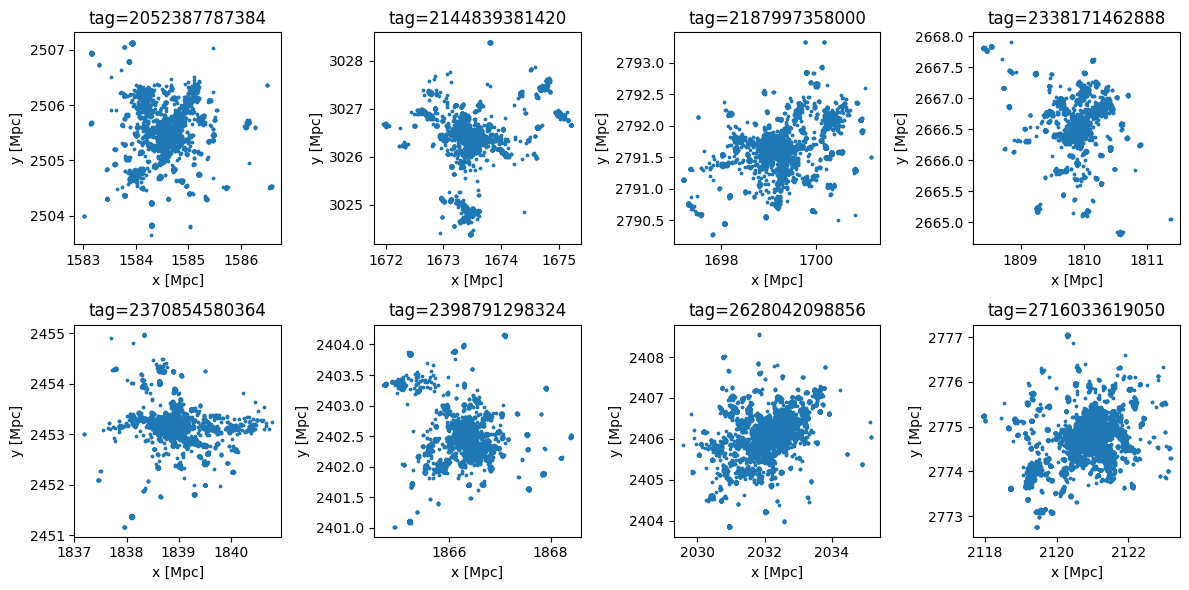

In [ ]:
#|eval: false
 
tags = np.unique(gal_tag).astype(int)
n_tags = 8 # len(tags)
tags = tags[:n_tags]  # Limit to first n_tags for testing
ncols = min(4, n_tags)
nrows = -(-n_tags // ncols)  # integer ceiling without math.ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
axes = np.atleast_2d(axes)

for i, gal_tag_selected in enumerate(tags):
    r, c = divmod(i, ncols)
    ax = axes[r, c]
    gal_tag_cond = np.where(gal_tag == gal_tag_selected)
    ax.scatter(x[gal_tag_cond], y[gal_tag_cond], s=3, alpha=1.0)
    ax.set_title(f'tag={gal_tag_selected}')
    ax.set_xlabel('x [Mpc]')
    ax.set_ylabel('y [Mpc]')

for j in range(i+1, nrows*ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#|eval: false

def scatter_subset(x, y, hue, mask, **kws):
    sns.scatterplot(x=x[mask], y=y[mask], hue=hue[mask], **kws)

In [ ]:
#|eval: false

plt.figure(figsize=(10, 10))

df = pd.DataFrame(np.array([gal_tag, age, np.log10(metal + 1e-5), np.log10(mass)]).T, columns=['gal-tag', 'age','log_metal','log_mass'])
df1 = pd.DataFrame(np.array([age[gal_tag_cond], np.log10(metal + 1e-10)[gal_tag_cond], np.log10(mass)[gal_tag_cond]]).T, columns=['age','log_metal','log_mass'])


df_all = pd.concat([df.assign(dataset='all'), df1.assign(dataset='tag-select')])


g = sns.PairGrid(df, hue="gal-tag", palette = "Paired", diag_sharey=False)
# g.map_lower(scatter_subset, mask=df["gal-tag"] == np.unique(gal_tag)[0])
g.map_upper(scatter_subset, mask=df["gal-tag"] != 0, alpha=0.8, legend=False)
g.map_lower(sns.kdeplot, alpha=0.5, levels=10, legend=False, fill=False)
g.map_diag(sns.kdeplot, fill=True, legend=False, warn_singular=False, alpha=0.5)
g.add_legend()
g.fig.set_size_inches(15,15)

(array([ 149.,  342.,  956., 1387., 1789., 2695., 3524., 4454., 2469.,
         285.]),
 array([0.        , 0.08420227, 0.16840453, 0.25260681, 0.33680907,
        0.42101133, 0.50521362, 0.58941585, 0.67361814, 0.75782043,
        0.84202266]),
 <BarContainer object of 10 artists>)

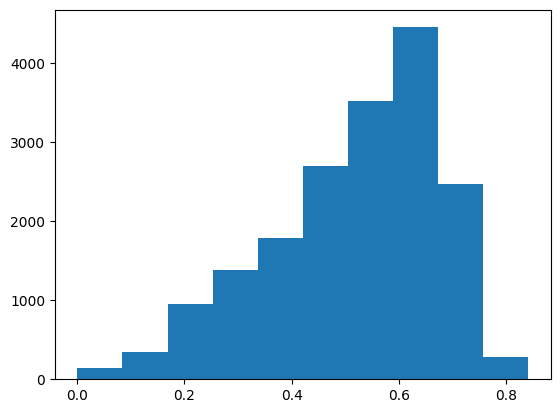

In [ ]:
#|eval: false

plt.hist(age[np.where(gal_tag == np.unique(gal_tag)[0])])

gal_tag_idx: 0, gal_tag: 2052387787384
gal_tag_idx: 1, gal_tag: 2144839381420
gal_tag_idx: 2, gal_tag: 2187997358000
gal_tag_idx: 3, gal_tag: 2338171462888
gal_tag_idx: 4, gal_tag: 2370854580364


/tmp/ipykernel_2972074/3070900267.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<matplotlib.legend.Legend>

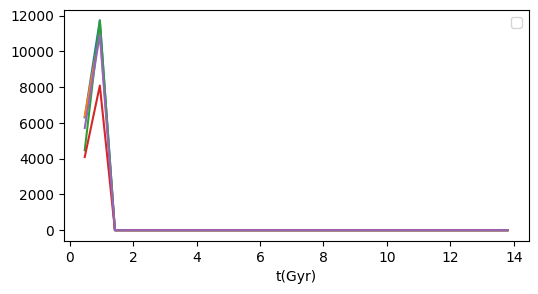

In [ ]:
#|eval: false

plt.figure(figsize=(6, 3))
for gal_tag_idx in range(5):
    print(f"gal_tag_idx: {gal_tag_idx}, gal_tag: {np.unique(gal_tag)[gal_tag_idx]}")
    gal_tag_condition = np.where(gal_tag == np.unique(gal_tag)[gal_tag_idx])
    h, b = np.histogram(age[gal_tag_condition], bins=np.linspace(0, 13.8, 30));
    # plt.plot(b[1:], np.cumsum(h), label='cumulative binned')
    # if (h.max() > 50):
    
    
    plt.plot(b[1:], h)
# plt.yscale('log')
plt.xlabel('t(Gyr)')
plt.legend()

In [ ]:
#| hide

import nbdev; nbdev.nbdev_export()